Student Performance Analysis using Python

Introduction:
Student performance is influenced by several factors such as study habits, lifestyle, and attendance. The objective of this project is to analyze student performance data using Python and identify the factors that have the greatest impact on final grades.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
df = pd.read_csv("data/student-por.csv")

In [10]:
df.head(10)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


In [11]:
df.shape

(649, 33)

In [12]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

The dataset contains information about 649 students and 33 attributes. These attributes include personal details, family background, study habits, lifestyle choices, and academic scores. The final grade (G3) is considered the target variable since it represents the student's overall academic performance.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [14]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


Before starting the analysis, the dataset was examined to ensure the data was suitable for analysis. The dataset was checked for missing values, duplicate records, and data types. Since no missing values or duplicate records were found, the dataset was ready for further analysis without any major preprocessing.

In [24]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

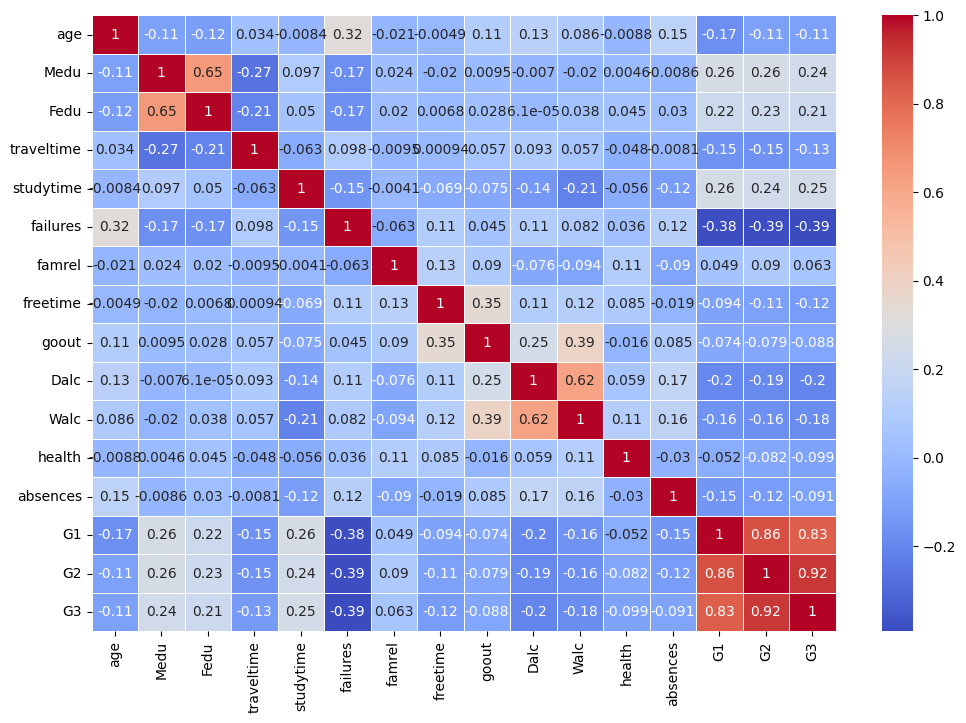

In [18]:
numeric_df = df.select_dtypes(include=['int64']) 
corr=numeric_df.corr()
corr["G3"].sort_values(ascending=False)
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap='coolwarm',linewidths=0.5)
plt.show()

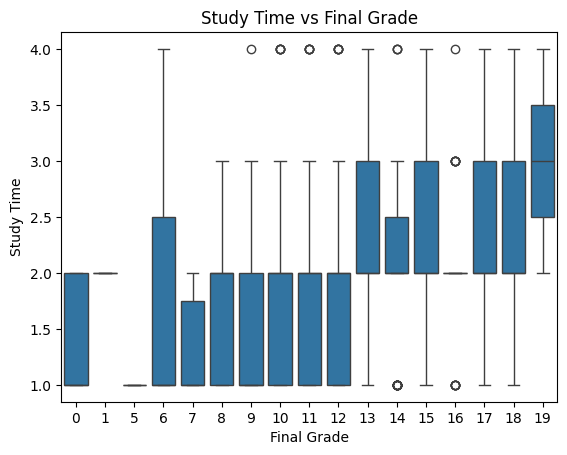

In [19]:
sns.boxplot(x='G3',y='studytime',data=df)
plt.title('Study Time vs Final Grade')
plt.xlabel('Final Grade')
plt.ylabel('Study Time')
plt.show()

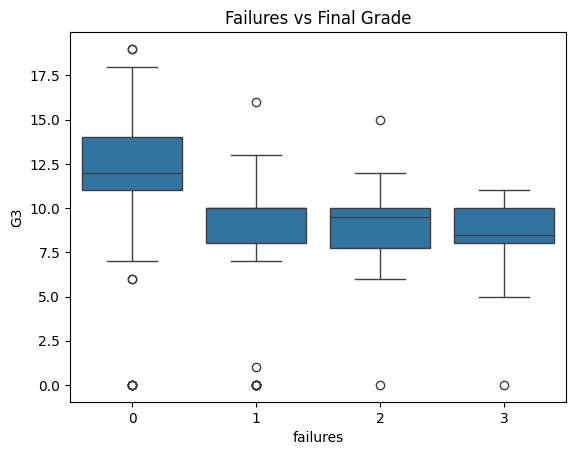

In [20]:
sns.boxplot(x="failures", y="G3", data=df)

plt.title("Failures vs Final Grade")

plt.show()

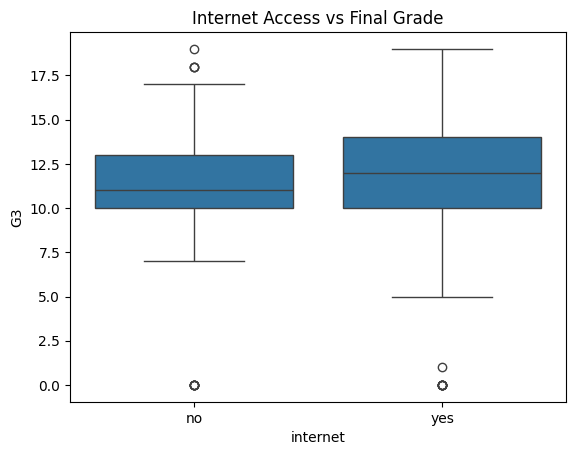

In [21]:
sns.boxplot(x="internet", y="G3", data=df)

plt.title("Internet Access vs Final Grade")

plt.show()

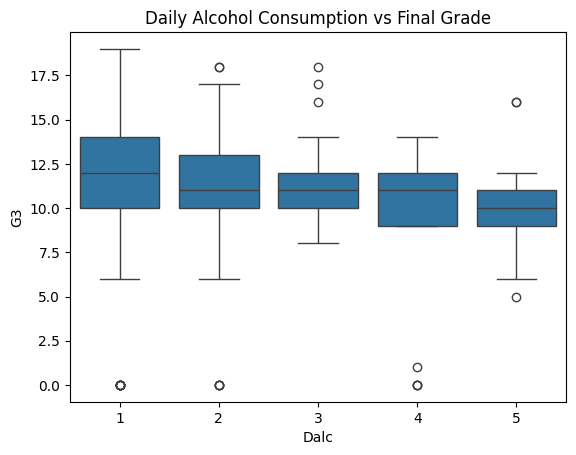

In [22]:
sns.boxplot(x="Dalc", y="G3", data=df)

plt.title("Daily Alcohol Consumption vs Final Grade")

plt.show()

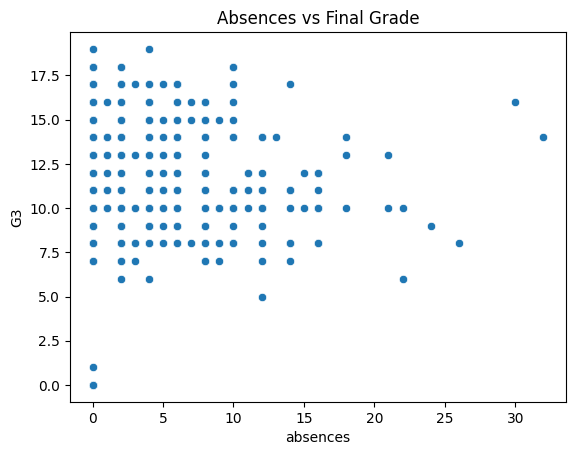

In [23]:
sns.scatterplot(x="absences", y="G3", data=df)

plt.title("Absences vs Final Grade")

plt.show()

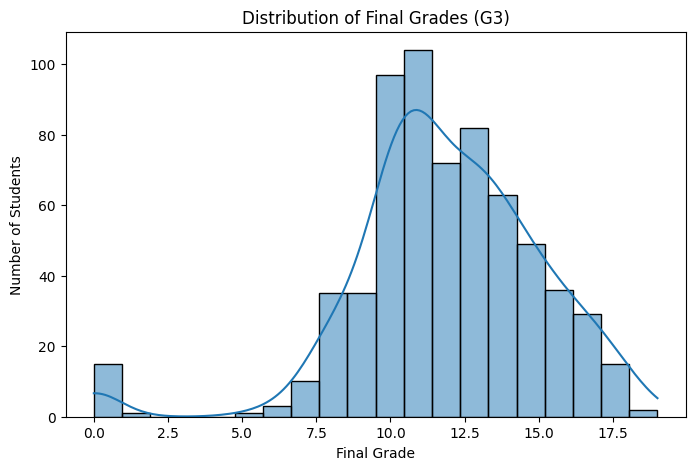

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

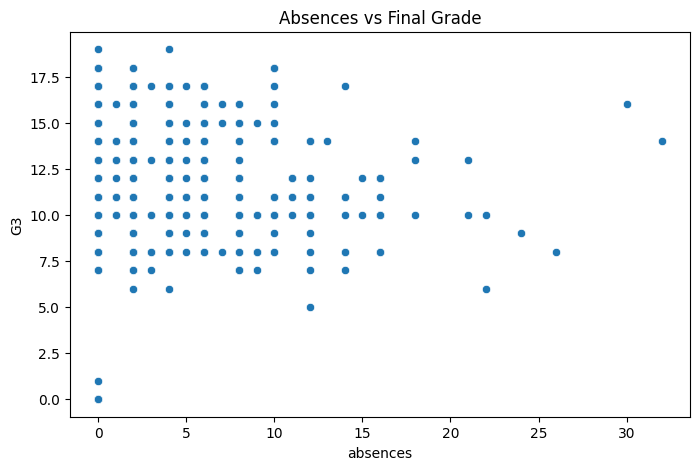

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="absences",
    y="G3",
    data=df
)
plt.title("Absences vs Final Grade")
plt.show()

The visualizations and statistical analysis helped identify several interesting relationships between different student attributes and their final grades. The observations from this analysis provide a better understanding of the factors that may contribute to academic success.

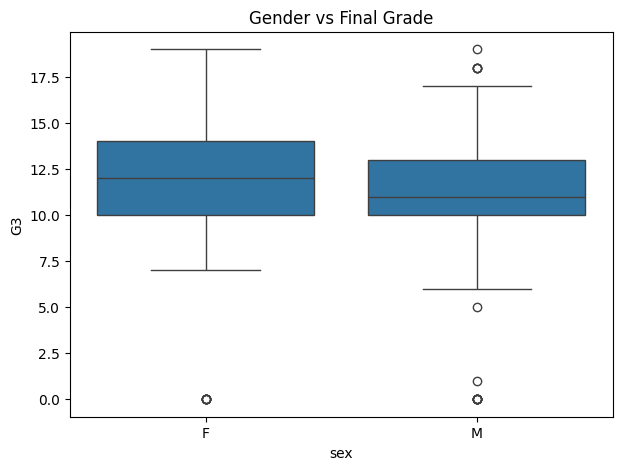

In [27]:
plt.figure(figsize=(7,5))
sns.boxplot(x="sex",y="G3",data=df)
plt.title("Gender vs Final Grade")
plt.show()

CONCLUSION:

This project demonstrates how Python can be used to analyze educational data and extract meaningful insights. Understanding these relationships can help students, parents, and educational institutions make informed decisions to improve academic performance.